In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on socioeconomic variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [2]:
#pulling standardized socioeconomic variables
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic.csv')
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str).str.zfill(6)

In [3]:
# show missing counts per column
print(tract_socioeconomic.isna().sum().sort_values(ascending=False).head(20))

# fraction missing per column
print((tract_socioeconomic.isna().mean()).sort_values(ascending=False).head(20))

# how many rows have any missing
print("Rows with any NaN:", tract_socioeconomic.isna().any(axis=1).sum(), " / ", len(tract_socioeconomic))

# optionally inspect rows with missing
missing_rows = tract_socioeconomic[tract_socioeconomic.isna().any(axis=1)]
missing_rows.head()


median_household_income                     48
american_indian_alaska_native                0
pct_over65                                   0
pct_with_disability                          0
population_below_50pct_poverty               0
population_civilian_noninstitutionalized     0
population_over65                            0
population_with_disability                   0
rent_30_to_34_pct_income                     0
rent_35_to_39_pct_income                     0
rent_40_to_49_pct_income                     0
rent_50_plus_pct_income                      0
renter_occupied_housing_units                0
some_other_race                              0
total_households_in_internet_table           0
total_households_vehicle_data                0
total_housing_units                          0
total_population                             0
total_renters                                0
two_or_more_races                            0
dtype: int64
median_household_income                     0.0

,american_indian_alaska_native,asian_alone,bachelors_degree,black_alone,female_65_66,female_67_69,female_70_74,female_75_79,female_80_84,female_85_plus,...,renter_occupied_housing_units,some_other_race,total_households_in_internet_table,total_households_vehicle_data,total_housing_units,total_population,total_renters,two_or_more_races,white_alone,TRACT
50,-0.169677,-0.412668,-1.237962,-0.713423,-1.122729,-0.953614,-0.964382,-1.204844,-1.060743,-0.457997,...,-1.138209,-0.667024,-2.002619,-2.002619,-2.002619,-1.893817,-1.138209,-0.914575,-1.485004,37007920302
55,-0.142175,-0.375424,-1.233484,-0.179932,-1.122729,-0.764597,-1.296124,-1.150463,-1.060743,-0.843800,...,-1.267610,-0.586770,-2.344428,-2.344428,-2.344428,-1.280129,-1.267610,-0.796686,-1.116347,37007980000
142,-0.188011,-0.412668,-1.284979,-0.925466,-1.122729,-1.256040,-1.337591,-1.204844,-1.060743,-0.843800,...,-1.267610,-0.667024,-2.344428,-2.344428,-2.344428,-2.234882,-1.267610,-1.001900,-1.750493,37019990100
202,-0.073420,-0.399125,-0.167770,-0.861176,-0.540299,-0.651187,-0.397657,2.184873,0.693159,9.425907,...,0.197304,-0.667024,-0.775768,-0.775768,-0.775768,-1.001232,0.197304,-0.884011,-0.340514,37021003108
327,-0.188011,-0.412668,-1.284979,-0.925466,-1.122729,-1.256040,-1.337591,-1.204844,-1.060743,-0.843800,...,-1.267610,-0.667024,-2.344428,-2.344428,-2.344428,-2.234882,-1.267610,-1.001900,-1.750493,37031980100


In [4]:
#Dropping the tracts with NAs
tract_socioeconomic_clean = tract_socioeconomic.dropna()

#Keeping derived calculations only
ses_vars = [
    "median_household_income",
    "pct_below_50pct_poverty",
    "pct_no_vehicle",
    "pct_renters_cost_burdened",
    "pct_over65",
    "pct_with_disability",
    "pct_nonwhite"
]

In [5]:
# Separate features and ID
X = tract_socioeconomic_clean.drop(columns=['TRACT'])  
X = X[ses_vars] 
tract_ids = tract_socioeconomic_clean['TRACT']      


## Scree Plot

To see how many PCs to keep

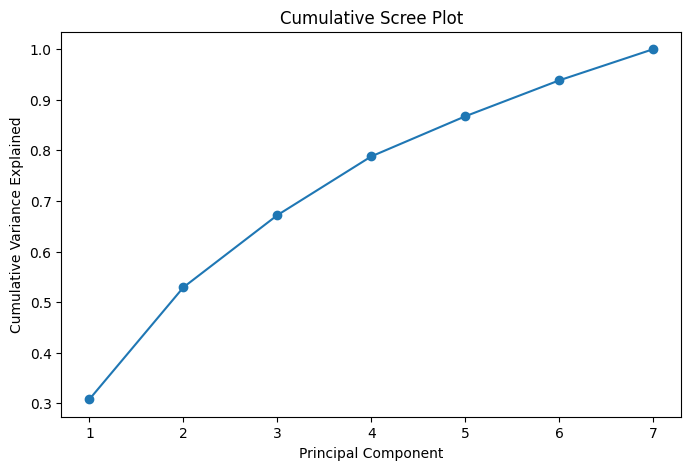

In [6]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

PC1: ~32%

PC2: ~18% (cumulative ~50%)

PC3: ~16% (cumulative ~66%)

PC4: ~13% (cumulative ~79%)

PC5: ~10% (cumulative ~89%)

PC6: ~8% (cumulative ~97%)

PC7: the rest

PC 1-3 is probably sufficient

## Running PCA for 3 components

In [7]:
# Keeping first three principle components
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(X)

In [8]:
# Turn PCA scores into a dataframe
socioeconomic_tract_pca_scores = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2', 'PC3']
)
socioeconomic_tract_pca_scores['TRACT'] = tract_ids.values   # add back id

# Get PCA loadings
socioeconomic_tract_loadings = pd.DataFrame(
    pca.components_.T,     # each row = variable, each column = PC
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)



PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3.

tract_socioeconomic_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract socioeconomic axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, and PC3 represent). The are weights linking original variables to each principal component.

In [9]:
socioeconomic_tract_loadings.to_csv('data_processed/socioeconomic_pca_results/socioeconomics pca loadings.csv', index=True)

## Loadings Interpretation:

### PC1

Structural Socioeconomic Disadvantage & Racial Composition

Higher tracts: higher poverty, higher racial minority populations, lower income, younger populations, more disability, more rent burden

Low tracts: wealthier, older populations, more white, lower poverty, lower disability

### PC2

Aging & Transportation Isolation

Higher: older populations, low vehicle access, poor, less disability though

Lower: younger, higher income, more disability, better vehicle access

### PC3

Urban Transportation Access vs Suburban Housing Cost Burden

high: far lower rent burden, strongly low vehicle access, highest score for disability though (could represent urban cores)

low: high rent burden, higher vehicle access, lower disability

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

Your advisor wants:

    • Cluster tracts based on PC1, PC2, PC3 scores
    • THEN examine outage metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which types of communities experience which outages?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

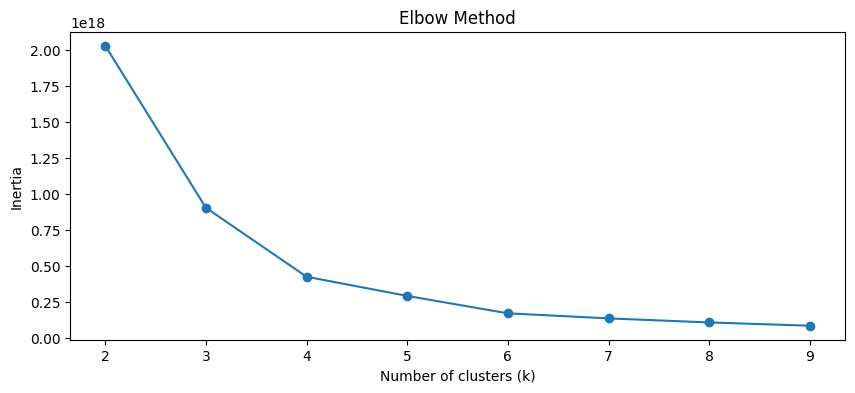

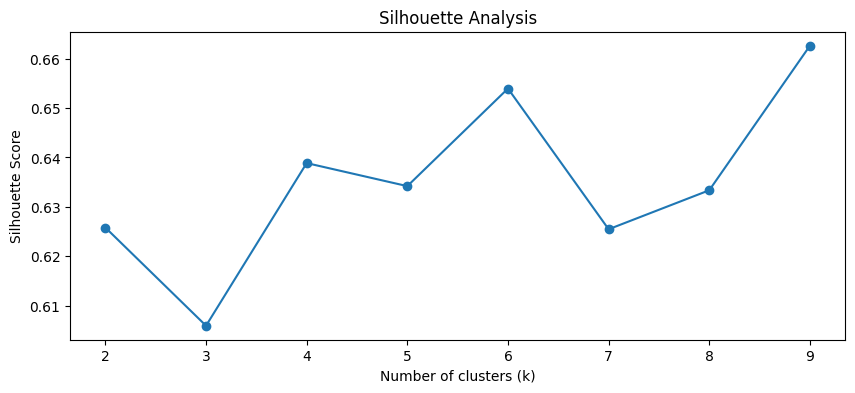

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(socioeconomic_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(socioeconomic_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 4

## Run clustering (k-means / hierarchical)

In [11]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
socioeconomic_tract_pca_scores['cluster'] = kmeans.fit_predict(socioeconomic_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [12]:
#pulling unscaled socioeconomic variables
tract_socioeconomic_unscaled = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_socioeconomic_unscaled['TRACT'] = tract_socioeconomic_unscaled['TRACT'].astype(str).str.zfill(6)

df = tract_socioeconomic_unscaled.merge(socioeconomic_tract_pca_scores[['TRACT','cluster']], on='TRACT')

socioeconomic_cluster_profiles = df.groupby('cluster')[ses_vars].mean()


It does not seem like NC census tracts fall into sharply distinct socioeconomic groups with these socioeconomic variables. So I instead want to identify SES outliers with PCA Distance. These would be socioeconomic "extreme" tracts.

## Identify standout tracts directly using PCA scores and distances

### Identify SES Outliers Using PCA Distance

In [13]:
pc_df = socioeconomic_tract_pca_scores[['PC1','PC2','PC3']].copy()
pc_df['TRACT'] = socioeconomic_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,TRACT,distance
111,-5.753165,10.203218,8.864188,37019020307,14.689397
1723,-0.248679,4.557266,7.147838,37127010801,8.480690
1925,5.181080,3.445750,-3.833075,37147000101,7.308162
953,3.429725,4.951888,4.127960,37081011500,7.302346
1964,0.829267,2.140734,5.893037,37147002004,6.324422
2596,5.766489,1.495202,-0.919431,37195000801,6.027717
2529,4.114050,2.517282,-3.219593,37189920601,5.798957
1300,5.630067,0.755928,1.048991,37107010300,5.776631
125,-3.954972,3.642247,-1.465088,37019020504,5.572634
2106,-1.033510,2.811771,4.592777,37161960101,5.483412


### Identify extremes along individual SES axes

In [14]:
#Finding extremes along individual SES axes
pc_df.sort_values('PC1').head(10)  # most disadvantaged
pc_df.sort_values('PC1').tail(10)  # most advantaged

pc_df.sort_values('PC2')           # seniors with mobility constraints
pc_df.sort_values('PC3')           # older suburban stability vs rent pressure


,PC1,PC2,PC3,TRACT,distance
1925,5.181080,3.445750,-3.833075,37147000101,7.308162
1685,-2.375735,3.507506,-3.304714,37125950303,5.372881
2529,4.114050,2.517282,-3.219593,37189920601,5.798957
2223,-1.244215,1.094622,-2.987613,37175960601,3.416446
300,0.050112,2.751220,-2.906004,37031970401,4.002072
...,...,...,...,...,...
1267,-1.020428,2.399533,4.446788,37101041301,5.154896
2106,-1.033510,2.811771,4.592777,37161960101,5.483412
1964,0.829267,2.140734,5.893037,37147002004,6.324422
1723,-0.248679,4.557266,7.147838,37127010801,8.480690


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top (wealth vs disadvantage), then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

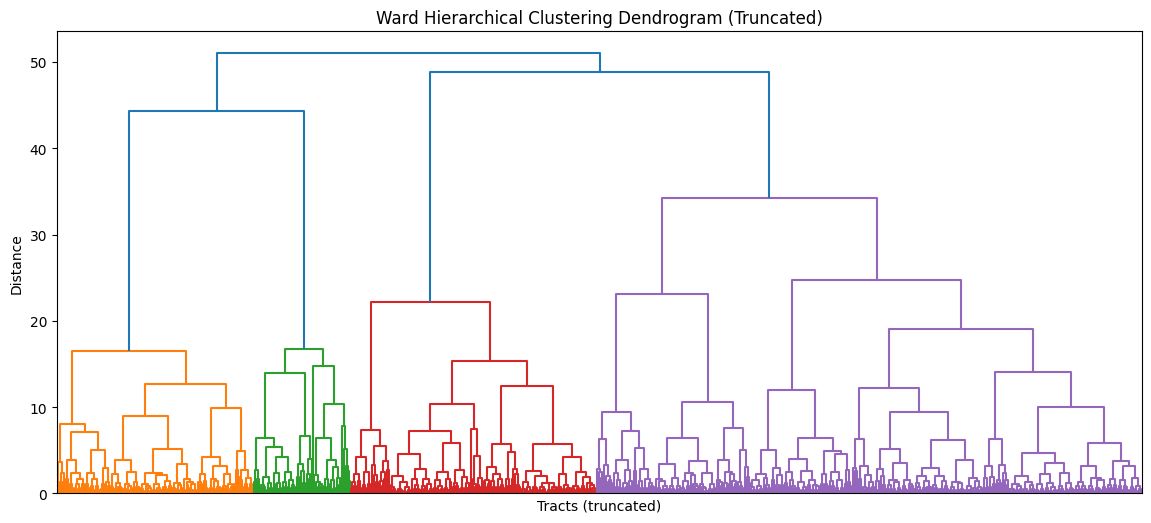

In [16]:
# Use the PCA scores for clustering
X = socioeconomic_tract_pca_scores[['PC1', 'PC2', 'PC3']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = socioeconomic_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

In [17]:
labels = fcluster(Z, 4, criterion='maxclust')
socioeconomic_tract_pca_scores['hc_cluster'] = labels

cluster_profiles = (
    tract_socioeconomic_clean
    .merge(socioeconomic_tract_pca_scores[['TRACT','hc_cluster']], on='TRACT')
    .groupby('hc_cluster')[ses_vars]
    .mean()
)
print(cluster_profiles)

cluster_profiles.to_csv("data_processed/socioeconomic_pca_results/socioeconomics_cluster_profiles.csv", index=True)


            median_household_income  pct_below_50pct_poverty  pct_no_vehicle  \
hc_cluster                                                                     
1                         -0.814703                 1.074544       -0.092105   
2                         -0.507738                 0.209500        2.166980   
3                         -0.252835                 0.046035       -0.327608   
4                          0.498333                -0.425262       -0.180735   

            pct_renters_cost_burdened  pct_over65  pct_with_disability  \
hc_cluster                                                               
1                            0.583251   -0.493496             0.533662   
2                           -0.365935    0.301438            -0.052879   
3                            0.486663    0.781971            -0.775457   
4                           -0.318849   -0.181889             0.235065   

            pct_nonwhite  
hc_cluster                
1               1.11

Looks like Ward's method tells us more useful information compared to K Means.

Note: these are Z-scores because SES variables were standardized, so positive = higher-than-average, negative = lower-than-average.

Cluster 1: High-poverty, high-minority, rent-burdened, younger communities
- Very high poverty (+1.07)
- Very high nonwhite share (+1.12)
- Low income (-0.81)
- High rent burden (+0.58)
- Younger (-0.49)
- Higher disability (+0.53)
- Normal vehicle access (-0.09, near mean)

Interpretation:
This could be structurally disadvantaged, high-poverty minority cluster. More urban cores, historically disadvantaged neighborhoods, high financial stress, younger, high disability.

Cluster 2: Transit-poor, older, moderate-poverty suburbs with very low vehicle access

- Extremely high "no vehicle" rate (+2.17)
- Moderately older (+0.30)
- Low rent burden (-0.36)
- Moderate poverty (+0.21)
- Low disability (-0.05)
- Slightly above-average nonwhite (+0.17)
- Below-average income (-0.50)

Interpretation:
These are older, lower-income, transit-dependent suburban or urban areas. The defining feature is EXTREMELY high lack of vehicle access, this is the transportation vulnerability cluster.

Cluster 3: Older, white, low-income but not high-poverty communities (rural aging areas)
- Oldest population (+0.78)
- Lowest disability (-0.78)
- Low poverty (+0.05 near average)
- Low income (-0.25)
- Very white (-0.55)
- Normal rent burden (+0.49)
- Slightly fewer vehicles (-0.33)

Interpretation:
Places with aging populations, modest income, low diversity, might be rural demographic patterns

Cluster 4: Higher-income, lower-poverty, whiter communities with low burden
- Highest income (+0.50)
- Lowest poverty (-0.43)
- Low rent burden (-0.31)
- Low nonwhite (-0.23)
- Slightly low disability (+0.23)
- Slightly younger (-0.18)
- Normal vehicle access (-0.18)

Interpretation:
Most looks like stable, higher-income communities with minimal socioeconomic vulnerability.

### Map PCs or SES variables directly

Because clusters are mild, mapping PC1–PC3 across NC may tell a richer story than clustering.

For example:

map 1: Structural Disadvantage

map 2: Aging and Transportation Isolation

map 3: Urban Transportation Access vs Suburban Housing Cost Burden

map 4: Ward clusters

In [18]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID']#.str[-6:]  # extract 6-digit tract code
tract_geo = tract_geo.to_crs(epsg=4326)

# Ensure TRACT columns are strings and zero-padded to 6 digits
#socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
#tract_geo['TRACT'] = tract_geo['TRACT'].astype(str).str.zfill(6)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/socioeconomic_pca_results/socioeconomic_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


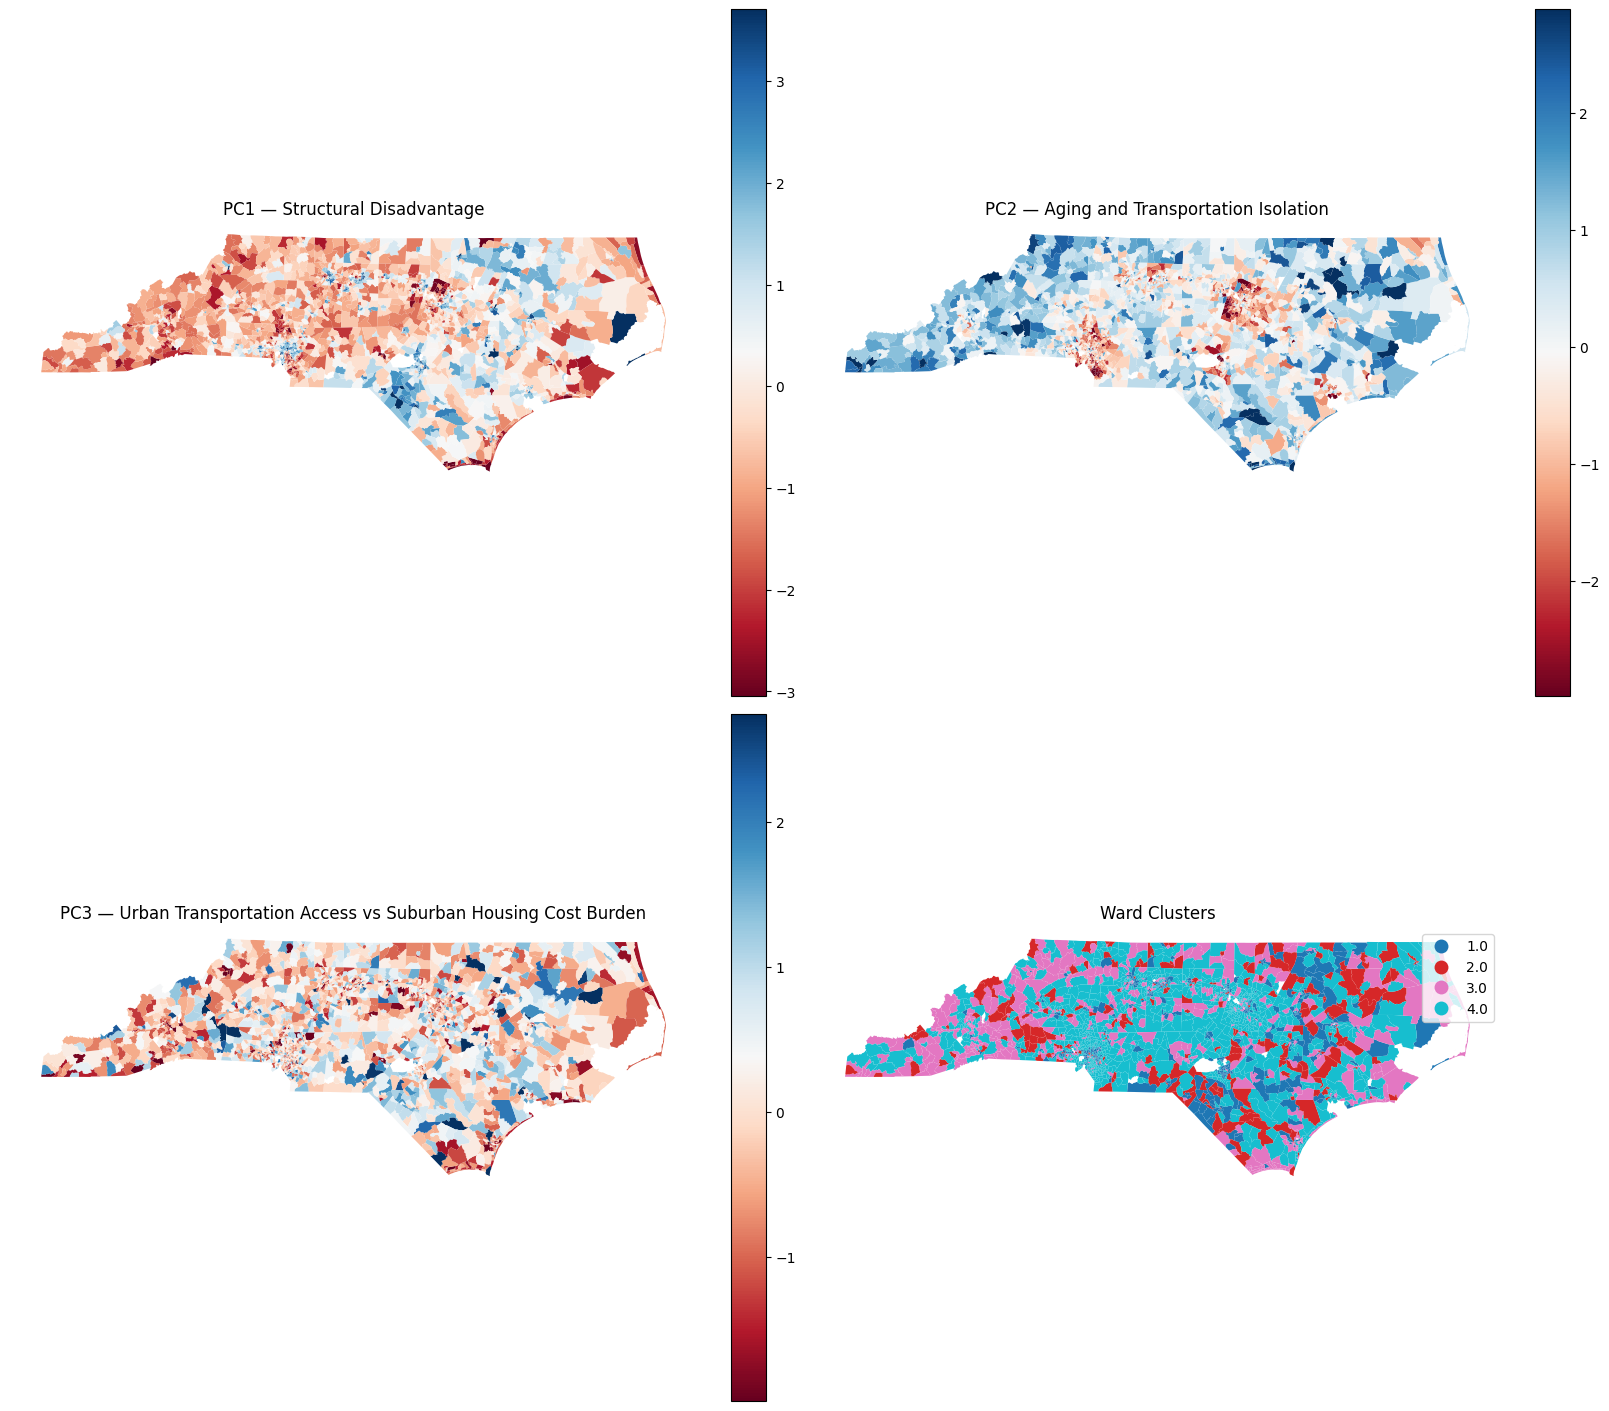

In [19]:
variables = ['PC1','PC2','PC3','hc_cluster']
titles = ['PC1 — Structural Disadvantage', 'PC2 — Aging / Mobility', 'PC3 — Older Suburban Stability', 'Ward clusters']

fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

variables = ['PC1', 'PC2', 'PC3', 'hc_cluster']
titles = [
    'PC1 — Structural Disadvantage',
    'PC2 — Aging and Transportation Isolation',
    'PC3 — Urban Transportation Access vs Suburban Housing Cost Burden',
    'Ward Clusters'
]

# axes is a 2x2 numpy array; flatten to 1D list of axes
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]  # <-- HERE IS THE FIX: ax is now a single Axes object

    if var == 'hc_cluster':
        # categorical map
        gdf.plot(
            column=var,
            ax=ax,
            categorical=True,
            legend=True,
            cmap='tab10',
            linewidth=0,
            edgecolor='none'
        )
    else:
        # continuous PCs with diverging colormap
        vmin = gdf[var].quantile(0.01)
        vmax = gdf[var].quantile(0.99)
        gdf.plot(
            column=var,
            ax=ax,
            cmap='RdBu',
            legend=True,
            vmin=vmin,
            vmax=vmax,
            linewidth=0,
            edgecolor='none'
        )

    ax.set_title(titles[i], fontsize=12)
    ax.set_axis_off()

plt.savefig(
    "data_processed/socioeconomic_pca_results/maps_pcs_and_cluster.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Merge with outage + weather summaries (tract)

I have:
- tract_outages
- tract_weather

Which are summaries of outages and weather for each tract.

This will help compute:
- Outages per cluster
- Durations per cluster
- Weather exposure per cluster

In [20]:
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
#socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str).str.zfill(6)
#tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)
#tract_weather['TRACT'] = tract_weather['TRACT'].astype(str).str.zfill(6)

socioeconomic_tract_pca_scores['TRACT'] = socioeconomic_tract_pca_scores['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = socioeconomic_tract_pca_scores[['TRACT','PC1','PC2','PC3','hc_cluster']].merge(
    tract_outages, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
)

# Bring in population for rates
pops = tract_socioeconomic_clean[['TRACT','total_population']].copy()
pops['TRACT'] = pops['TRACT'].astype(str).str.zfill(6)
df = df.merge(pops, on='TRACT', how='left')

#DEFINING METRICS TO SUMMARIZE (from tract_outages and tract_weather)
outage_metrics = [
    'total_outages',
    'mean_duration_hours',
    'median_duration_hours',
    'max_duration_hours',
    'total_duration_hours',
    'mean_customers_affected',
    'max_customers_affected',
    'total_customers_affected',
    'total_customer_minutes_out',
    'pct_outages_in_summer',
    'pct_outages_in_winter'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days',
    'outage_weather_day_count'
]

#keeping metrics that exist
metrics = [m for m in (outage_metrics + weather_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('hc_cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('hc_cluster')

Note that length of tract_outages and tract_weather are the same, but shorter than socioeconomic_tract_pca_scores. Might be worth double checking because means some tracts might be missing weather data primarily.

In [21]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('hc_cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [22]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each hc_cluster for a small set of key metrics:
key_metrics = ['total_outages','total_duration_hours','total_customer_minutes_out','mean_duration_hours','max_gust_during_outage_days']
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False])

Saved: data_processed/socioeconomic_pca_results/outlier_tracts_static_map_polygons_only.png


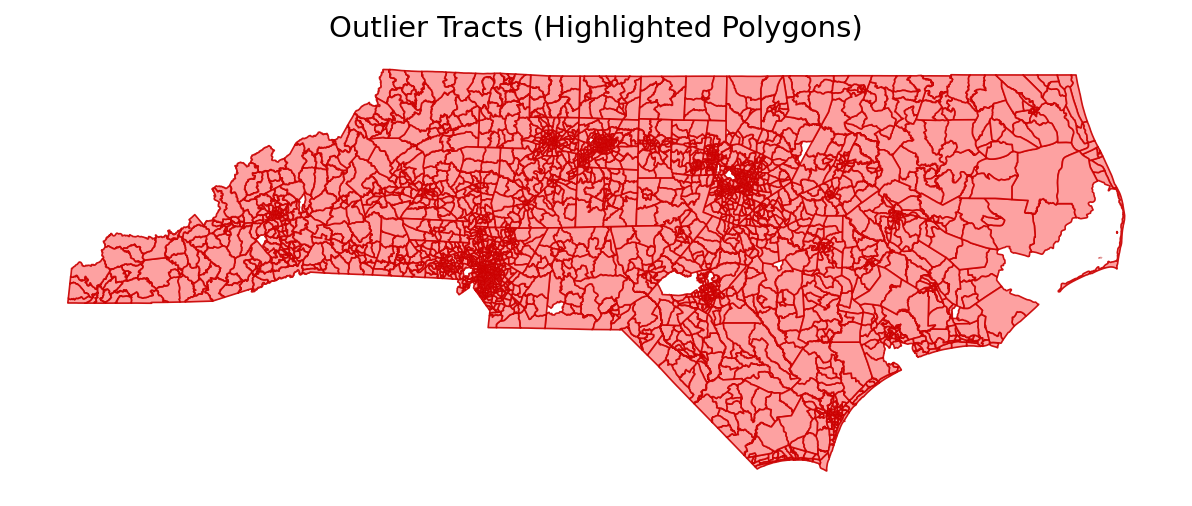

In [23]:
gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

# Save to file
out_path = "data_processed/socioeconomic_pca_results/outlier_tracts_static_map_polygons_only.png"
plt.savefig(out_path, bbox_inches='tight', pad_inches=0.1)
print(f"Saved: {out_path}")

plt.show()

In [24]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/socioeconomic_pca_results/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/socioeconomic_pca_results/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/socioeconomic_pca_results/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


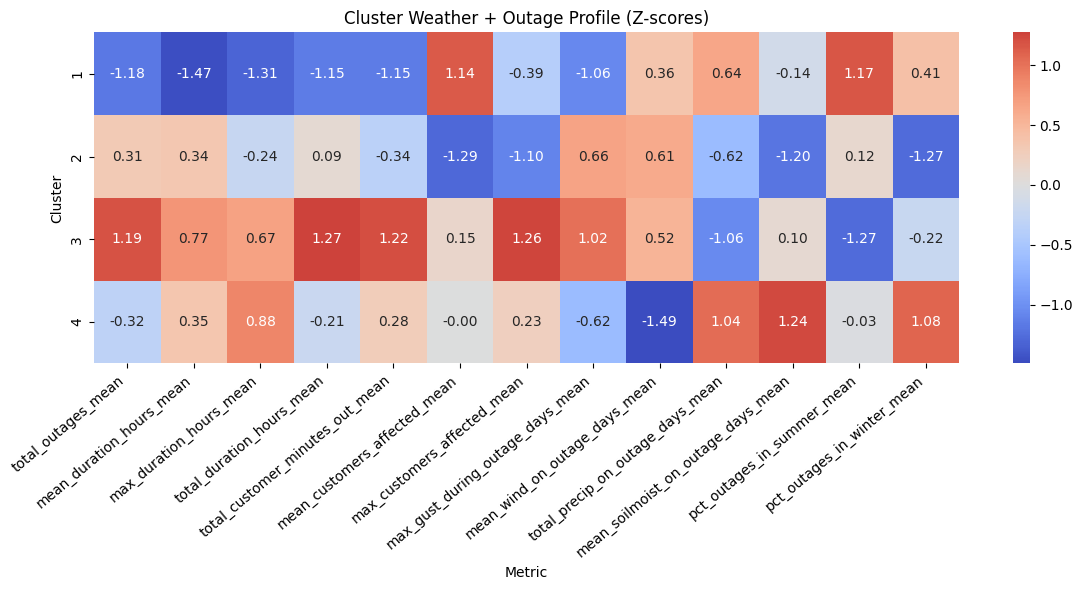

In [25]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'total_outages_mean',
    'mean_duration_hours_mean',
    'max_duration_hours_mean',
    'total_duration_hours_mean',
    'total_customer_minutes_out_mean',
    'mean_customers_affected_mean',
    'max_customers_affected_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
    'pct_outages_in_summer_mean',
    'pct_outages_in_winter_mean'
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

heatmap_data = cluster_summary_std.set_index('hc_cluster')[cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Outage Profile (Z-scores)")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

plt.savefig("data_processed/socioeconomic_pca_results/cluster_weather_outage_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()